# Markov Processes
### States, transitions, and why the past doesn't matter

This notebook builds Markov chains from first principles — discrete and continuous time, stationary distributions, absorbing states — and connects them forward to the things they underpin: PageRank, language model token generation, and the RL setup in the Actor-Critic notebook.

---

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib import rcParams
from matplotlib.patches import FancyArrowPatch

# ── Dark theme ────────────────────────────────────────────────────────────────
BG      = '#0d1117'
SURFACE = '#161b22'
ACCENT  = '#e05c5c'
TEXT    = '#c9d1d9'
MUTED   = '#484f58'
BLUE    = '#58a6ff'
GREEN   = '#3fb950'
YELLOW  = '#d29922'
PURPLE  = '#bc8cff'

rcParams.update({
    'figure.facecolor':  BG,
    'axes.facecolor':    SURFACE,
    'axes.edgecolor':    MUTED,
    'axes.labelcolor':   TEXT,
    'xtick.color':       TEXT,
    'ytick.color':       TEXT,
    'text.color':        TEXT,
    'grid.color':        MUTED,
    'grid.alpha':        0.3,
    'legend.facecolor':  SURFACE,
    'legend.edgecolor':  MUTED,
    'figure.dpi':        110,
})

np.random.seed(42)
np.set_printoptions(precision=4, suppress=True)
print("Ready.")

Ready.


## Part 1 — The Markov property

A **Markov chain** is a sequence of random variables $X_0, X_1, X_2, \ldots$ taking values in some state space $\mathcal{S}$, with one defining property:

$$P(X_{t+1} = s' \mid X_t = s,\ X_{t-1},\ X_{t-2},\ \ldots) = P(X_{t+1} = s' \mid X_t = s)$$

The future depends only on the present state — not on how you got there. The entire history is irrelevant once you know where you are now. This is the **Markov property**, sometimes called *memorylessness*.

It's a strong assumption, and deliberately so — it makes the mathematics tractable. The interesting question is not whether real systems are perfectly Markovian (most aren't), but whether the Markov approximation is good enough to be useful. Spoiler: it usually is.

### A concrete example

Weather modelled as three states: **Sunny**, **Cloudy**, **Rainy**.

Today's weather depends only on yesterday's — not last week's. Whether that's actually true is a meteorological question. As a modelling assumption it lets us write down a complete description of the system in a single matrix.

In [5]:
# ── Transition matrix ──────────────────────────────────────────────────────────
# P[i, j] = probability of going FROM state i TO state j
# Each ROW must sum to 1 (you have to go somewhere)

states = ['Sunny', 'Cloudy', 'Rainy']
n = len(states)

#              → Sunny  Cloudy  Rainy
P = np.array([
    [0.70,   0.20,   0.10],   # from Sunny
    [0.30,   0.40,   0.30],   # from Cloudy
    [0.20,   0.30,   0.50],   # from Rainy
])

print("Transition matrix P:")
print(f"{'':10s}", end='')
for s in states:
    print(f"{s:>10s}", end='')
print()
for i, row_state in enumerate(states):
    print(f"{row_state:10s}", end='')
    for j in range(n):
        print(f"{P[i,j]:>10.2f}", end='')
    print(f"  (sum={P[i].sum():.1f})")

print("\nEach row sums to 1.0 — confirmed:", np.allclose(P.sum(axis=1), 1.0))

Transition matrix P:
               Sunny    Cloudy     Rainy
Sunny           0.70      0.20      0.10  (sum=1.0)
Cloudy          0.30      0.40      0.30  (sum=1.0)
Rainy           0.20      0.30      0.50  (sum=1.0)

Each row sums to 1.0 — confirmed: True


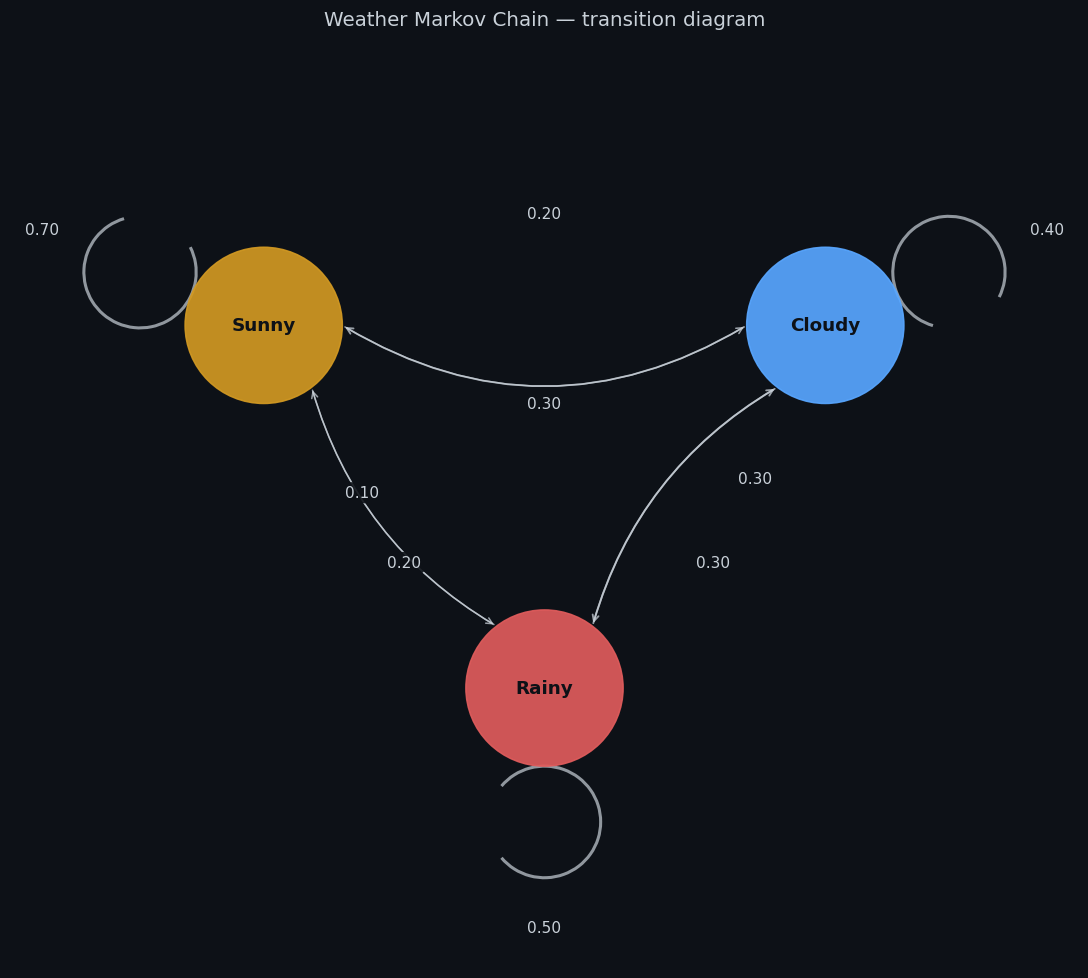

In [6]:
# ── Visualise the transition diagram ──────────────────────────────────────────
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(10, 9))
ax.set_xlim(-1.9, 1.9)
ax.set_ylim(-1.8, 1.5)
ax.axis('off')
ax.set_title('Weather Markov Chain — transition diagram', color=TEXT, fontsize=13, pad=14)

node_positions = {
    'Sunny':  np.array([-1.0,  0.5]),
    'Cloudy': np.array([ 1.0,  0.5]),
    'Rainy':  np.array([ 0.0, -0.8]),
}
node_colors_d = {'Sunny': YELLOW, 'Cloudy': BLUE, 'Rainy': ACCENT}
node_r = 0.28

def _unit(v): return v / np.linalg.norm(v)

# (from, to, prob, bend, label_xy) — label coords chosen to avoid all overlaps
diagram_edges = [
    ('Sunny',  'Cloudy', 0.20,  0.30, ( 0.0,  0.90)),
    ('Cloudy', 'Sunny',  0.30, -0.30, ( 0.0,  0.22)),
    ('Sunny',  'Rainy',  0.10,  0.20, (-0.65, -0.10)),
    ('Rainy',  'Sunny',  0.20, -0.20, (-0.50, -0.35)),
    ('Cloudy', 'Rainy',  0.30,  0.20, ( 0.75, -0.05)),
    ('Rainy',  'Cloudy', 0.30, -0.20, ( 0.60, -0.35)),
]

for frm, to, prob, bend, lxy in diagram_edges:
    p1, p2 = node_positions[frm], node_positions[to]
    u = _unit(p2 - p1)
    ax.annotate('',
        xy=p2 - u * node_r, xytext=p1 + u * node_r,
        arrowprops=dict(
            arrowstyle='->', color=TEXT, alpha=0.75,
            connectionstyle=f'arc3,rad={bend}',
            lw=max(1.0, prob * 4.0)
        ))
    ax.text(lxy[0], lxy[1], f'{prob:.2f}',
            ha='center', va='center', fontsize=10, color=TEXT, zorder=6,
            bbox=dict(boxstyle='round,pad=0.2', facecolor=BG, alpha=0.9, edgecolor='none'))

# Self-loops: arc outside each node, pointing away from centroid
centroid = np.mean(list(node_positions.values()), axis=0)
loop_r = 0.20
for state, prob in [('Sunny', 0.70), ('Cloudy', 0.40), ('Rainy', 0.50)]:
    p = node_positions[state]
    out = _unit(p - centroid)
    loop_c = p + out * (node_r + loop_r)
    arc = mpatches.Arc(loop_c, loop_r * 2, loop_r * 2,
        angle=np.degrees(np.arctan2(out[1], out[0])) - 90,
        theta1=40, theta2=320,
        color=TEXT, alpha=0.7, linewidth=2.0, zorder=2)
    ax.add_patch(arc)
    ax.text(*(loop_c + out * (loop_r + 0.18)), f'{prob:.2f}',
            ha='center', va='center', fontsize=10, color=TEXT, zorder=6,
            bbox=dict(boxstyle='round,pad=0.2', facecolor=BG, alpha=0.9, edgecolor='none'))

# Nodes drawn last so they sit on top of edges
for state, p in node_positions.items():
    ax.add_patch(plt.Circle(p, node_r, color=node_colors_d[state], alpha=0.92, zorder=4))
    ax.text(p[0], p[1], state, ha='center', va='center',
            fontsize=12, color=BG, fontweight='bold', zorder=5)

plt.tight_layout()
plt.show()

## Part 2 — Multi-step transitions

If I'm in state $i$ today, what's the probability of being in state $j$ in two days?

I could enumerate every possible path: Sunny→Sunny→Rainy, Sunny→Cloudy→Rainy, Sunny→Rainy→Rainy. But that becomes combinatorially explosive for more steps.

The elegant answer: **matrix multiplication**.

The $n$-step transition matrix is simply $P^n$ — the transition matrix raised to the $n$th power.

$$P^{(n)}_{ij} = P(X_{t+n} = j \mid X_t = i)$$

This works because matrix multiplication is exactly the operation of summing over all intermediate paths — the same sum you'd compute by hand, but handled automatically.

In [7]:
# ── Multi-step transitions ─────────────────────────────────────────────────────
steps = [1, 2, 5, 10, 50]

print("Starting from Sunny — probability of each state after n steps:\n")
print(f"{'Steps':>6s}  {'Sunny':>10s}  {'Cloudy':>10s}  {'Rainy':>10s}")
print("─" * 42)

Pn = np.eye(n)   # P^0 = identity
step_count = 0

for target_step in steps:
    while step_count < target_step:
        Pn = Pn @ P
        step_count += 1
    row = Pn[0]   # starting from Sunny (index 0)
    print(f"{target_step:>6d}  {row[0]:>10.4f}  {row[1]:>10.4f}  {row[2]:>10.4f}")

print("\nNotice: the rows converge. After enough steps, the starting state")
print("stops mattering. This is the stationary distribution.")

Starting from Sunny — probability of each state after n steps:

 Steps       Sunny      Cloudy       Rainy
──────────────────────────────────────────
     1      0.7000      0.2000      0.1000
     2      0.5700      0.2500      0.1800
     5      0.4685      0.2794      0.2521
    10      0.4568      0.2825      0.2607
    50      0.4565      0.2826      0.2609

Notice: the rows converge. After enough steps, the starting state
stops mattering. This is the stationary distribution.


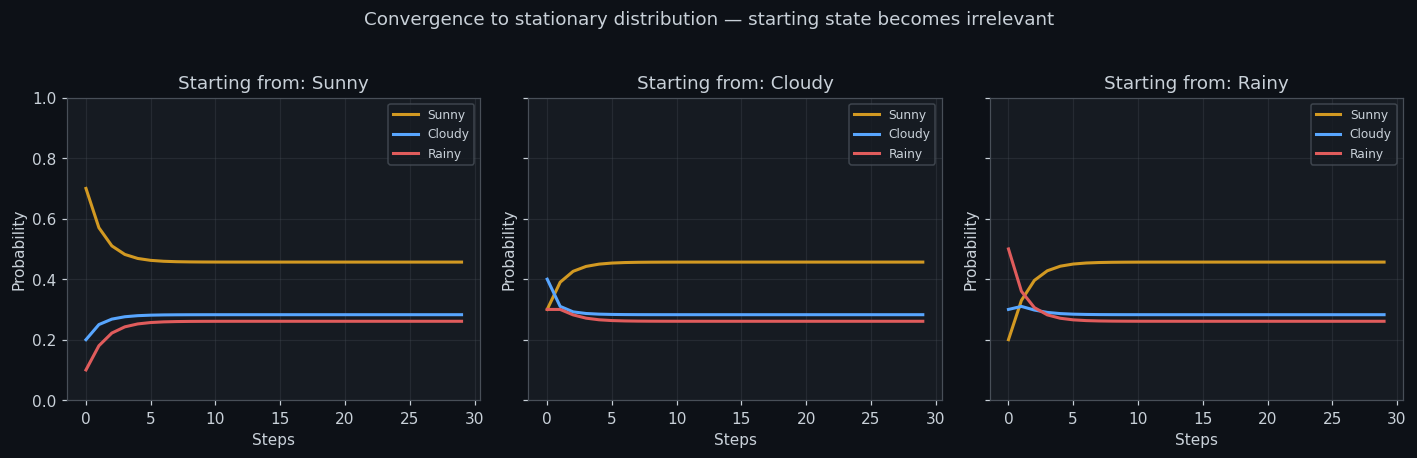

In [8]:
# ── Visualise convergence from all starting states ────────────────────────────
n_steps_plot = 30
all_rows = np.zeros((n_steps_plot, n, n))
Pn = np.eye(n)
for t in range(n_steps_plot):
    Pn = Pn @ P
    all_rows[t] = Pn

fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=True)
state_colors = [YELLOW, BLUE, ACCENT]

for start_idx, (ax, start_name) in enumerate(zip(axes, states)):
    for end_idx, (end_name, col) in enumerate(zip(states, state_colors)):
        ax.plot(all_rows[:, start_idx, end_idx],
                color=col, linewidth=2, label=end_name)
    ax.set_title(f'Starting from: {start_name}', color=TEXT)
    ax.set_xlabel('Steps')
    ax.set_ylabel('Probability')
    ax.legend(fontsize=8)
    ax.grid(True)
    ax.set_ylim(0, 1)

fig.suptitle('Convergence to stationary distribution — starting state becomes irrelevant',
             color=TEXT, y=1.03)
plt.tight_layout()
plt.show()

## Part 3 — The stationary distribution

After enough steps, the chain converges to a distribution $\pi$ that doesn't change with further transitions:

$$\pi P = \pi$$

This is the **stationary distribution** (also called the steady-state or invariant distribution). It's a left eigenvector of $P$ corresponding to eigenvalue 1.

There are two ways to find it:

**Method 1 — Power iteration**: keep multiplying $P$ by itself until rows stop changing. We just saw this above.

**Method 2 — Solve the eigenvector equation**: find $\pi$ such that $\pi P = \pi$ and $\sum_i \pi_i = 1$.

This rearranges to $(P^T - I)^T \pi = 0$ with the normalisation constraint — a linear system.

In [9]:
# ── Find stationary distribution analytically ─────────────────────────────────
# Solve π P = π  subject to  Σ π_i = 1
# Rearranges to: π (P - I) = 0
# Transpose:     (P^T - I)^T π^T = 0
# Add normalisation constraint as an extra equation

A = (P.T - np.eye(n))
# Replace last equation with normalisation constraint
A[-1] = 1.0
b = np.zeros(n)
b[-1] = 1.0

pi_analytic = np.linalg.solve(A, b)

# Method 2: eigendecomposition
eigenvalues, eigenvectors = np.linalg.eig(P.T)
# Find the eigenvector for eigenvalue = 1
idx = np.argmin(np.abs(eigenvalues - 1.0))
pi_eigen = np.real(eigenvectors[:, idx])
pi_eigen /= pi_eigen.sum()   # normalise

# Method 3: power iteration (from the plots above)
Pn = np.linalg.matrix_power(P, 1000)
pi_power = Pn[0]   # any row converges to π

print("Stationary distribution π — three methods:")
print(f"{'State':10s}  {'Linear solve':>14s}  {'Eigendecomp':>14s}  {'Power iter':>12s}")
print("─" * 56)
for i, s in enumerate(states):
    print(f"{s:10s}  {pi_analytic[i]:>14.6f}  {pi_eigen[i]:>14.6f}  {pi_power[i]:>12.6f}")

print(f"\nAll three agree: {np.allclose(pi_analytic, pi_eigen, atol=1e-5) and np.allclose(pi_analytic, pi_power, atol=1e-5)}")
print(f"\nInterpretation: in the long run, {pi_analytic[0]:.1%} of days are sunny,")
print(f"{pi_analytic[1]:.1%} cloudy, {pi_analytic[2]:.1%} rainy — regardless of starting state.")

Stationary distribution π — three methods:
State         Linear solve     Eigendecomp    Power iter
────────────────────────────────────────────────────────
Sunny             0.456522        0.456522      0.456522
Cloudy            0.282609        0.282609      0.282609
Rainy             0.260870        0.260870      0.260870

All three agree: True

Interpretation: in the long run, 45.7% of days are sunny,
28.3% cloudy, 26.1% rainy — regardless of starting state.


In [10]:
# ── Verify: π P = π ───────────────────────────────────────────────────────────
pi_next = pi_analytic @ P
print("Verification: π @ P")
print(f"  π:     {pi_analytic}")
print(f"  π @ P: {pi_next}")
print(f"  Equal: {np.allclose(pi_analytic, pi_next)}")

# ── Simulate and verify empirically ───────────────────────────────────────────
def simulate_chain(P, states, n_steps=100_000, start=0):
    state = start
    counts = np.zeros(len(states))
    for _ in range(n_steps):
        state = np.random.choice(len(states), p=P[state])
        counts[state] += 1
    return counts / n_steps

empirical = simulate_chain(P, states)
print("\nEmpirical frequencies (100k steps simulation):")
for s, emp, theory in zip(states, empirical, pi_analytic):
    print(f"  {s:8s}: empirical={emp:.4f}  theoretical={theory:.4f}")

Verification: π @ P
  π:     [0.4565 0.2826 0.2609]
  π @ P: [0.4565 0.2826 0.2609]
  Equal: True

Empirical frequencies (100k steps simulation):
  Sunny   : empirical=0.4570  theoretical=0.4565
  Cloudy  : empirical=0.2842  theoretical=0.2826
  Rainy   : empirical=0.2588  theoretical=0.2609


## Part 4 — Conditions for a stationary distribution to exist

Not every Markov chain converges to a unique stationary distribution. Two conditions are needed:

**Irreducibility**: every state must be reachable from every other state. The chain can't get trapped in a subset of states. In our weather example, all three states communicate — you can always eventually get from Rainy to Sunny.

**Aperiodicity**: the chain can't be forced into a fixed cycle. A chain that alternates A→B→A→B is periodic with period 2 and doesn't converge. Self-loops (non-zero diagonal entries in P) guarantee aperiodicity.

A chain that is both irreducible and aperiodic is called **ergodic**. Ergodic chains:
- Have a unique stationary distribution
- Converge to it from any starting state
- Have time averages that equal ensemble averages (the ergodic theorem)

This last point is what makes simulation useful: run one long chain instead of many parallel chains.

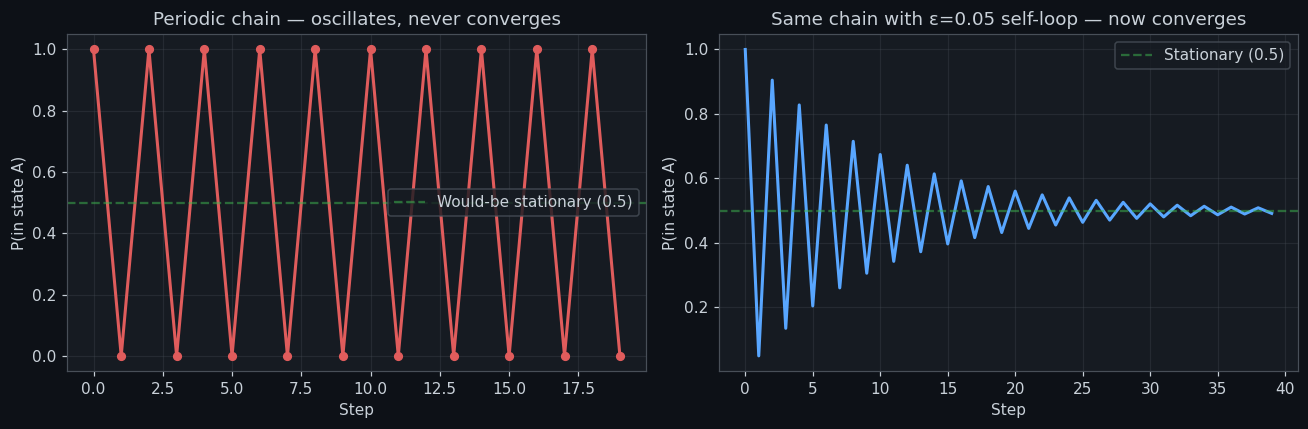

In [11]:
# ── Demonstrate a periodic (non-ergodic) chain ────────────────────────────────
# This chain alternates strictly: A→B→A→B...
# It never converges to a stationary distribution.

P_periodic = np.array([
    [0.0, 1.0],   # from A: always go to B
    [1.0, 0.0],   # from B: always go to A
])

# Track probability of being in state A, starting from A
prob_in_A = []
v = np.array([1.0, 0.0])   # start in A with certainty
for t in range(20):
    prob_in_A.append(v[0])
    v = v @ P_periodic

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.plot(prob_in_A, color=ACCENT, linewidth=2, marker='o', markersize=5)
ax.axhline(0.5, color=GREEN, linestyle='--', alpha=0.5, label='Would-be stationary (0.5)')
ax.set_title('Periodic chain — oscillates, never converges', color=TEXT)
ax.set_xlabel('Step')
ax.set_ylabel('P(in state A)')
ax.legend()
ax.grid(True)

# Fix: add tiny self-loop probability
epsilon = 0.05
P_fixed = np.array([
    [epsilon, 1-epsilon],
    [1-epsilon, epsilon],
])
prob_in_A_fixed = []
v = np.array([1.0, 0.0])
for t in range(40):
    prob_in_A_fixed.append(v[0])
    v = v @ P_fixed

ax = axes[1]
ax.plot(prob_in_A_fixed, color=BLUE, linewidth=2)
ax.axhline(0.5, color=GREEN, linestyle='--', alpha=0.5, label='Stationary (0.5)')
ax.set_title(f'Same chain with ε={epsilon} self-loop — now converges', color=TEXT)
ax.set_xlabel('Step')
ax.set_ylabel('P(in state A)')
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()

## Part 5 — Absorbing states

An **absorbing state** is one you can never leave: $P_{ii} = 1$. Once the chain enters an absorbing state, it stays there forever.

Absorbing chains model processes with terminal outcomes: a random walk that ends when it hits 0 or $N$, a game that ends in win/loss, a molecule that reacts and becomes inert.

The interesting questions for absorbing chains:
- **Absorption probability**: starting from transient state $i$, what's the probability of eventually reaching absorbing state $j$?
- **Expected absorption time**: how many steps until the chain reaches any absorbing state?

Both have clean matrix solutions via the **fundamental matrix** $N = (I - Q)^{-1}$, where $Q$ is the sub-matrix of transition probabilities between transient states.

In [12]:
# ── Gambler's ruin ────────────────────────────────────────────────────────────
# A gambler starts with £k, bets £1 each round.
# Win with prob p, lose with prob 1-p.
# Game ends at £0 (ruin) or £N (target).
# States: 0, 1, 2, ..., N  where 0 and N are absorbing.

N_wealth = 6   # target wealth
p_win    = 0.45  # probability of winning each round (slightly unfair)
n_states = N_wealth + 1

# Build full transition matrix
P_gambler = np.zeros((n_states, n_states))
P_gambler[0, 0] = 1.0         # absorbing: ruin
P_gambler[N_wealth, N_wealth] = 1.0  # absorbing: target
for i in range(1, N_wealth):
    P_gambler[i, i+1] = p_win
    P_gambler[i, i-1] = 1 - p_win

print("Gambler's ruin transition matrix (states 0 to 6):")
print(P_gambler)

# Fundamental matrix approach
# Transient states: 1 to N-1
transient = list(range(1, N_wealth))
Q = P_gambler[np.ix_(transient, transient)]   # transient → transient
R = P_gambler[np.ix_(transient, [0, N_wealth])]  # transient → absorbing

# Fundamental matrix: N = (I - Q)^{-1}
# N[i,j] = expected number of times in transient state j, starting from transient state i
fund = np.linalg.inv(np.eye(len(transient)) - Q)

# Absorption probabilities: B = N @ R
# B[i, j] = probability of being absorbed into absorbing state j from transient state i
B = fund @ R

# Expected steps to absorption: t = N @ 1
t_expected = fund @ np.ones(len(transient))

print("\nAbsorption probabilities (ruin vs target):")
print(f"{'Start £':>8s}  {'P(ruin)':>10s}  {'P(target)':>10s}  {'E[steps]':>10s}")
print("─" * 44)
for i, state in enumerate(transient):
    print(f"{'£'+str(state):>8s}  {B[i,0]:>10.4f}  {B[i,1]:>10.4f}  {t_expected[i]:>10.2f}")

Gambler's ruin transition matrix (states 0 to 6):
[[1.   0.   0.   0.   0.   0.   0.  ]
 [0.55 0.   0.45 0.   0.   0.   0.  ]
 [0.   0.55 0.   0.45 0.   0.   0.  ]
 [0.   0.   0.55 0.   0.45 0.   0.  ]
 [0.   0.   0.   0.55 0.   0.45 0.  ]
 [0.   0.   0.   0.   0.55 0.   0.45]
 [0.   0.   0.   0.   0.   0.   1.  ]]

Absorption probabilities (ruin vs target):
 Start £     P(ruin)   P(target)    E[steps]
────────────────────────────────────────────
      £1      0.9048      0.0952        4.29
      £2      0.7884      0.2116        7.30
      £3      0.6461      0.3539        8.77
      £4      0.4722      0.5278        8.33
      £5      0.2597      0.7403        5.58


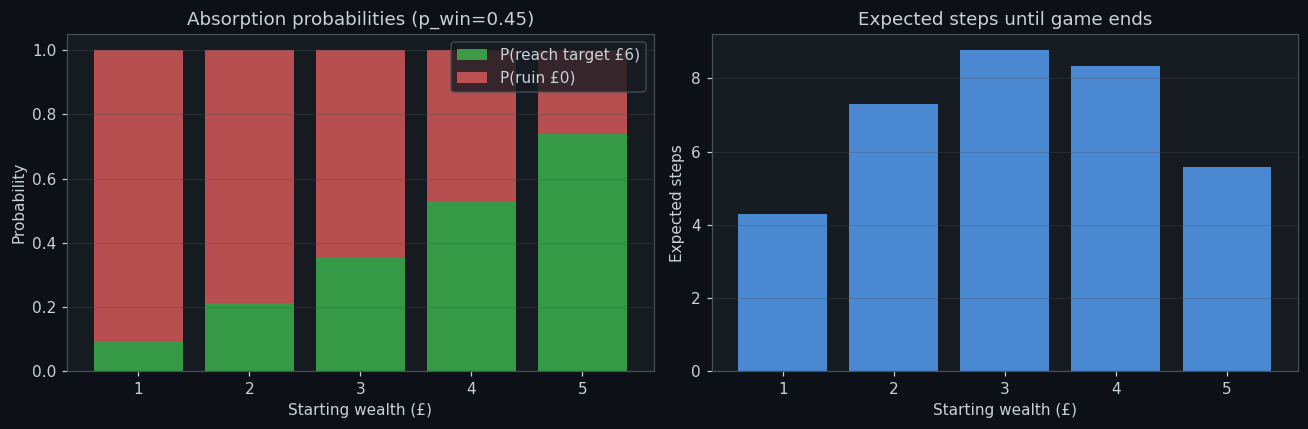

Even starting at £5 of £6 target, ruin probability is 26.0% — the house edge matters.


In [13]:
# ── Visualise absorption probabilities ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.bar(transient, B[:, 1], color=GREEN,  alpha=0.8, label='P(reach target £6)')
ax.bar(transient, B[:, 0], color=ACCENT, alpha=0.8,
       bottom=B[:, 1], label='P(ruin £0)')
ax.set_title(f"Absorption probabilities (p_win={p_win})", color=TEXT)
ax.set_xlabel('Starting wealth (£)')
ax.set_ylabel('Probability')
ax.set_xticks(transient)
ax.legend()
ax.grid(True, axis='y')

ax = axes[1]
ax.bar(transient, t_expected, color=BLUE, alpha=0.8)
ax.set_title('Expected steps until game ends', color=TEXT)
ax.set_xlabel('Starting wealth (£)')
ax.set_ylabel('Expected steps')
ax.set_xticks(transient)
ax.grid(True, axis='y')

plt.tight_layout()
plt.show()

print(f"Even starting at £5 of £6 target, ruin probability is {B[4,0]:.1%} — the house edge matters.")

## Part 6 — PageRank: stationary distribution as importance

PageRank (Brin & Page, 1998) is a direct application of Markov chain stationary distributions to web graph ranking.

The model: a **random surfer** clicks links at random. At each page, they follow one of the outgoing links uniformly at random — or with probability $d$ (the **damping factor**, typically 0.85), they jump to a completely random page.

This defines a Markov chain over web pages. The **stationary distribution of this chain is the PageRank** — the fraction of time the random surfer spends at each page in the long run.

Pages that many important pages link to get visited more often → higher stationary probability → higher rank.

The damping factor ensures the chain is ergodic even if some pages have no outgoing links (dangling nodes).

In [14]:
# ── PageRank on a small web graph ─────────────────────────────────────────────
# 6 pages, links between them
page_names = ['Home', 'About', 'Blog', 'Post1', 'Post2', 'Contact']
n_pages = len(page_names)

# Adjacency matrix: links[i,j] = 1 means page i links to page j
links = np.array([
    #H  A  B  P1 P2 Co
    [0, 1, 1, 0, 0, 1],   # Home links to About, Blog, Contact
    [1, 0, 0, 0, 0, 1],   # About links to Home, Contact
    [1, 0, 0, 1, 1, 0],   # Blog links to Home, Post1, Post2
    [0, 0, 1, 0, 1, 0],   # Post1 links to Blog, Post2
    [0, 0, 1, 1, 0, 0],   # Post2 links to Blog, Post1
    [1, 1, 0, 0, 0, 0],   # Contact links to Home, About
])

# Convert to transition matrix: normalise rows
row_sums = links.sum(axis=1, keepdims=True)
P_web = links / row_sums

# PageRank with damping factor d
d = 0.85
n_p = n_pages
# Google matrix: with prob d follow a link, with prob (1-d) jump anywhere
G = d * P_web + (1 - d) * np.ones((n_p, n_p)) / n_p

# Find stationary distribution via power iteration
v = np.ones(n_p) / n_p   # start uniform
for _ in range(100):
    v = v @ G

pagerank = v

print("PageRank scores:")
ranked = sorted(zip(page_names, pagerank), key=lambda x: -x[1])
for rank, (name, score) in enumerate(ranked, 1):
    bar = '█' * int(score * 200)
    print(f"  {rank}. {name:10s}: {score:.4f}  {bar}")

print(f"\nSum of all PageRank scores: {pagerank.sum():.4f}  (always 1 — it's a distribution)")

PageRank scores:
  1. Home      : 0.2080  █████████████████████████████████████████
  2. Blog      : 0.2080  █████████████████████████████████████████
  3. About     : 0.1460  █████████████████████████████
  4. Post1     : 0.1460  █████████████████████████████
  5. Post2     : 0.1460  █████████████████████████████
  6. Contact   : 0.1460  █████████████████████████████

Sum of all PageRank scores: 1.0000  (always 1 — it's a distribution)


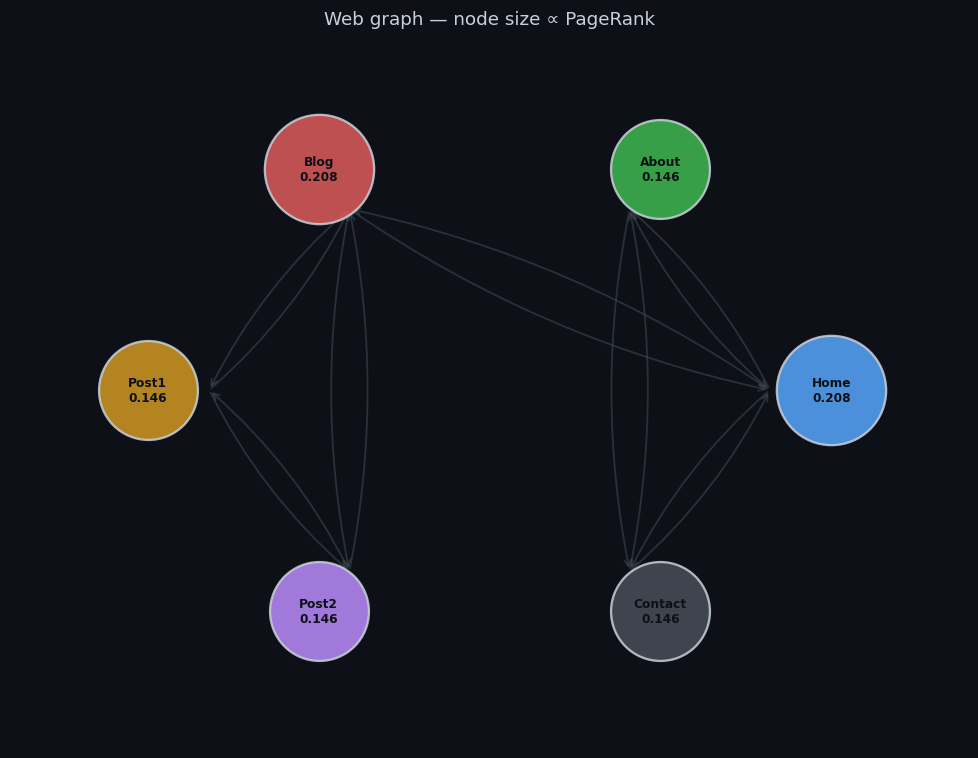

In [15]:
# ── Visualise the web graph with PageRank as node size ────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))
ax.set_xlim(-1.4, 1.4)
ax.set_ylim(-1.4, 1.4)
ax.axis('off')
ax.set_title('Web graph — node size ∝ PageRank', color=TEXT, fontsize=12)

# Circular layout
angles = np.linspace(0, 2*np.pi, n_pages, endpoint=False)
node_pos = {i: (np.cos(a), np.sin(a)) for i, a in enumerate(angles)}
node_colors = [BLUE, GREEN, ACCENT, YELLOW, PURPLE, MUTED]

# Draw edges
for i in range(n_pages):
    for j in range(n_pages):
        if links[i, j]:
            x1, y1 = node_pos[i]
            x2, y2 = node_pos[j]
            ax.annotate('',
                xy=(x2 * 0.82, y2 * 0.82),
                xytext=(x1 * 0.82, y1 * 0.82),
                arrowprops=dict(
                    arrowstyle='->', color=MUTED, alpha=0.5, lw=1.2,
                    connectionstyle='arc3,rad=0.1'
                ))

# Draw nodes
for i, name in enumerate(page_names):
    x, y = node_pos[i]
    size = 2000 + pagerank[i] * 15000
    ax.scatter(x, y, s=size, color=node_colors[i], alpha=0.85,
               zorder=3, edgecolors=TEXT, linewidths=1.5)
    ax.text(x, y, f"{name}\n{pagerank[i]:.3f}",
            ha='center', va='center', fontsize=8,
            color=BG, fontweight='bold', zorder=4)

plt.tight_layout()
plt.show()

## Part 7 — Markov chains in language models

A character-level or word-level language model is a Markov chain: the probability of the next token depends only on the current state (in the simplest case — the previous $n$ tokens for an $n$-gram model).

This is exactly what a first-order Markov chain over words does. The transition matrix $P$ where $P_{ij}$ = probability that word $j$ follows word $i$ can be estimated directly from a corpus by counting.

The limitation — and why we have transformers — is that a first-order Markov chain has no memory beyond the immediately previous token. "The bank by the river" and "The bank that approved the loan" require context further back than one step. Higher-order Markov chains (conditioning on the last $n$ tokens) help but the state space explodes exponentially.

Transformers replace the fixed-window Markov assumption with attention — dynamic, learned weighting of all previous tokens. But the sampling process at inference time (selecting the next token from the output distribution) is still a Markov chain: what's sampled depends only on the current context, not the full history of sampling decisions.

In [16]:
# ── First-order Markov language model ─────────────────────────────────────────
# Build a character-level transition matrix from a small corpus
# and generate text by following the chain

corpus = (
    "the cat sat on the mat the cat ate the rat "
    "the rat ran from the cat the mat was flat "
    "the cat and the rat sat on the flat mat "
    "a fat cat sat on a mat a rat ate a bat "
)

words  = corpus.split()
vocab  = sorted(set(words))
w2i    = {w: i for i, w in enumerate(vocab)}
n_vocab = len(vocab)

# Count transitions
counts = np.zeros((n_vocab, n_vocab))
for a, b in zip(words[:-1], words[1:]):
    counts[w2i[a], w2i[b]] += 1

# Normalise to get transition probabilities
row_sums = counts.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1   # avoid division by zero
P_lang = counts / row_sums

print(f"Vocabulary ({n_vocab} words): {vocab}")
print("\nTransition probabilities from 'the':")
the_idx = w2i['the']
for j, word in enumerate(vocab):
    if P_lang[the_idx, j] > 0:
        bar = '█' * int(P_lang[the_idx, j] * 30)
        print(f"  the → {word:8s}: {P_lang[the_idx, j]:.3f}  {bar}")

Vocabulary (15 words): ['a', 'and', 'ate', 'bat', 'cat', 'fat', 'flat', 'from', 'mat', 'on', 'ran', 'rat', 'sat', 'the', 'was']

Transition probabilities from 'the':
  the → cat     : 0.400  ████████████
  the → flat    : 0.100  ███
  the → mat     : 0.200  ██████
  the → rat     : 0.300  █████████


In [17]:
# ── Generate text by following the chain ──────────────────────────────────────
def generate_text(P, vocab, w2i, start_word, n_words=20, seed=None):
    if seed is not None:
        np.random.seed(seed)
    current = w2i[start_word]
    text = [start_word]
    for _ in range(n_words - 1):
        probs = P[current]
        if probs.sum() == 0:
            break
        current = np.random.choice(len(vocab), p=probs)
        text.append(vocab[current])
    return ' '.join(text)

print("Generated text (first-order Markov chain):\n")
for seed in range(4):
    print(f"  [{seed}] {generate_text(P_lang, vocab, w2i, 'the', n_words=15, seed=seed)}")

print("\nLocally coherent (consecutive pairs make sense) but globally repetitive.")
print("This is the Markov limitation: no memory beyond the previous word.")
print("A transformer attends to all previous tokens — the Markov assumption is abandoned.")

Generated text (first-order Markov chain):

  [0] the mat the mat the flat the flat the rat ran from the mat was
  [1] the flat the cat ate a bat
  [2] the flat mat the flat mat a bat
  [3] the mat the cat sat on the cat ate a fat cat sat on a

Locally coherent (consecutive pairs make sense) but globally repetitive.
This is the Markov limitation: no memory beyond the previous word.
A transformer attends to all previous tokens — the Markov assumption is abandoned.


## Part 8 — Markov Decision Processes: the RL connection

The Actor-Critic notebook used a **Markov Decision Process (MDP)** without naming it as such. An MDP extends a Markov chain with actions and rewards:

$$\text{MDP} = (\mathcal{S},\ \mathcal{A},\ P,\ R,\ \gamma)$$

| Symbol | What it is |
|--------|------------|
| $\mathcal{S}$ | State space |
| $\mathcal{A}$ | Action space |
| $P(s'\mid s, a)$ | Transition probabilities — now conditioned on action too |
| $R(s, a)$ | Reward function |
| $\gamma$ | Discount factor |

The Markov property still holds: $P(s_{t+1} \mid s_t, a_t, s_{t-1}, a_{t-1}, \ldots) = P(s_{t+1} \mid s_t, a_t)$.

The future depends only on the current state and action — not the full history. This is what makes RL tractable. Without the Markov property, you'd need to track the entire trajectory to make decisions, which is computationally unbounded.

CartPole is an MDP. The state is the 4-dimensional physics vector. The Markov property holds exactly because the physics equations only need the current state to compute the next one — velocities encode the history.

In [18]:
# ── Small MDP: grid world ─────────────────────────────────────────────────────
# 4 states in a line: S0 - S1 - S2 - S3(goal)
# Actions: left or right
# Slippery: with prob 0.1, you go the wrong way
# Reward: +10 on reaching S3, -1 otherwise

n_mdp_states  = 4
n_mdp_actions = 2  # 0=left, 1=right
slip = 0.1

# P_mdp[s, a, s'] = prob of going to s' from s taking action a
P_mdp = np.zeros((n_mdp_states, n_mdp_actions, n_mdp_states))
R_mdp = -np.ones((n_mdp_states, n_mdp_actions))   # -1 per step

for s in range(n_mdp_states - 1):  # S3 is absorbing
    for a in range(n_mdp_actions):
        intended = s + 1 if a == 1 else s - 1
        slipped  = s - 1 if a == 1 else s + 1
        intended = np.clip(intended, 0, n_mdp_states - 1)
        slipped  = np.clip(slipped,  0, n_mdp_states - 1)
        P_mdp[s, a, intended] += (1 - slip)
        P_mdp[s, a, slipped]  += slip

P_mdp[n_mdp_states-1, :, n_mdp_states-1] = 1.0  # goal is absorbing
R_mdp[:, 1] = np.where(np.arange(n_mdp_states) == n_mdp_states - 2, 9.0, -1.0)

print("MDP transition probabilities P(s' | s, action=right):")
print(f"{'From\\To':>10s}", end='')
for s in range(n_mdp_states):
    print(f"  S{s}", end='')
print()
for s in range(n_mdp_states):
    print(f"{'S'+str(s):>10s}", end='')
    for sp in range(n_mdp_states):
        print(f"  {P_mdp[s, 1, sp]:.2f}", end='')
    print()

print("\nKey difference from a plain Markov chain:")
print("The transition probabilities DEPEND ON THE ACTION TAKEN.")
print("The agent controls which transition matrix it's operating under.")
print("Finding the optimal policy = finding the best action at every state.")
print("That's what Actor-Critic/PPO is solving.")

SyntaxError: f-string expression part cannot include a backslash (2413130218.py, line 28)

## Summary

| Concept | What it is |
|---------|------------|
| **Markov property** | Future depends only on present state, not history |
| **Transition matrix P** | $P_{ij}$ = probability of going from state $i$ to state $j$; rows sum to 1 |
| **$n$-step transitions** | $P^n$ — matrix power gives transition probs after $n$ steps |
| **Stationary distribution** | $\pi$ such that $\pi P = \pi$; the long-run fraction of time in each state |
| **Ergodicity** | Irreducible + aperiodic → unique stationary distribution from any start |
| **Absorbing state** | $P_{ii} = 1$; chain can enter but never leave |
| **Fundamental matrix** | $N = (I-Q)^{-1}$; gives expected visits and absorption times |
| **PageRank** | Stationary distribution of a random surfer Markov chain over web pages |
| **MDP** | Markov chain + actions + rewards; the formal framework for RL |

---

### The key equations

**Markov property:**
$$\boxed{P(X_{t+1} = s' \mid X_t = s,\ X_{t-1}, \ldots) = P(X_{t+1} = s' \mid X_t = s)}$$

**Stationary distribution:**
$$\boxed{\pi P = \pi, \quad \sum_i \pi_i = 1}$$

**Fundamental matrix:**
$$\boxed{N = (I - Q)^{-1}}$$

---

## Things to try

- Change the weather transition matrix so Sunny is more persistent — how does the stationary distribution shift?
- Make the gambler's ruin fair ($p = 0.5$) — how does absorption time change vs $p = 0.45$?
- Add a 7th page to the web graph with no incoming links — what PageRank does it get? Why?
- Try a second-order Markov language model: condition on the last *two* words. Does the generated text improve?
- Set `d = 1.0` in PageRank (no random jumps) — what breaks, and why does the damping factor exist?